In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import sys
sys.path.append('/kaggle/input/entransformer-datasets')
import torch
from torch.utils.data import DataLoader

In [2]:
%%capture
!pip install darts==0.39.0
!pip install gluonts
!pip install lightning

### Deterministic Seed Setting



In [3]:

import os
import random
import numpy as np
import torch
import cv2
from transformers import set_seed
from datasets import disable_progress_bar
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# optional for debugging only:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

class Deterministic:
    def __init__(self):
        pass

    def init_all(self, seed=0, disable_list=['cuda_block']):
        random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
        if 'cuda_block' not in disable_list: # stuck when train deberta
            os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        if 'torch_deter_algo' not in disable_list: # consumn more gpu sometimes
            torch.use_deterministic_algorithms(True, warn_only=True)
        set_seed(seed)
        cv2.setRNGSeed(seed)
        disable_progress_bar()

deterministic = Deterministic()

In [4]:
import os
print(os.getcwd())

c:\Users\Anusha\engression\engression-ts\engressionts\experiments\solar


In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[2]   # .../engression-ts
sys.path.insert(0, str(project_root))

In [6]:
# import traceback

# print("=" * 80)
# print("Testing EnBEATS import...")
# print("=" * 80)

# try:
#     from engressionts.models.darts.nbeats import EnBEATSModel
#     print("\n✅ SUCCESS")
#     print(EnBEATSModel)

# except Exception as e:
#     print("\n❌ IMPORT FAILED")
#     print(f"\nException type: {type(e).__name__}")
#     print(f"\nException message:\n{e}")

#     print("\nFull traceback:")
#     traceback.print_exc()

# print("\n" + "=" * 80)

In [7]:
# import traceback

# print("=" * 80)
# print("Testing EnHiTS import...")
# print("=" * 80)

# try:
#     from engressionts.models.darts.nhits import EnHiTSModel
#     print("\n✅ SUCCESS")
#     print(EnHiTSModel)

# except Exception as e:
#     print("\n❌ IMPORT FAILED")
#     print(f"\nException type: {type(e).__name__}")
#     print(f"\nException message:\n{e}")

#     print("\nFull traceback:")
#     traceback.print_exc()

# print("\n" + "=" * 80)

### Importing Libraries

In [8]:
import torch
import torch.nn as nn
import pandas as pd
from typing import Tuple, Optional

from darts import TimeSeries
from darts.metrics import mae, rmse, smape, mase, rmsse
from darts.dataprocessing.transformers import Scaler

# Change this import to the model you want to evaluate.
# Example: EnBEATSModel, EnTransformerModel, EnTCNModel, etc.
from engressionts.models.darts.enbeats import EnBEATSModel

Could not import EnBlockRNNModel: No module named 'engressionts.models.darts.block_rnn_model'
Could not import EnChronos2Model: No module named 'engressionts.models.darts.chronos2_model'
Could not import EnDLinearModel: No module named 'engressionts.models.darts.dllinear_model'
Could not import EnBEATSModel: No module named 'engressionts.models.darts.nbeats'
Could not import EnHiTSModel: No module named 'engressionts.models.darts.nhits'
Could not import EnNLinearModel: No module named 'engressionts.models.darts.nlinear_model'
Could not import EnRNNModel: No module named 'engressionts.models.darts.rnn_model'
Could not import EnTCNModel: No module named 'engressionts.models.darts.tcn_model'
Could not import EnTFTModel: No module named 'engressionts.models.darts.tft_model'
Could not import EnTiDEModel: No module named 'engressionts.models.darts.tide_model'
Could not import EnTSMixerModel: No module named 'engressionts.models.darts.tsmixer_model'
Could not import EnTransformerModel: No mod

## Data Specific Params

In [9]:
PRED_LEN = 24
LAGS = (1, 24, 168)

## Importing Data and Formatting

In [10]:
import numpy as np
import pandas as pd

from gluonts.dataset.repository.datasets import get_dataset
from gluonts.dataset.multivariate_grouper import MultivariateGrouper

from darts import TimeSeries

def gluonts_item_to_darts_mv(item, freq: str) -> TimeSeries:
    # GluonTS start is often a pandas Period; convert safely
    start = item["start"].to_timestamp() if hasattr(item["start"], "to_timestamp") else pd.Timestamp(item["start"])

    # GluonTS multivariate target is typically shape (D, T)
    target = np.asarray(item["target"])
    if target.ndim != 2:
        raise ValueError(f"Expected multivariate target with ndim=2, got shape {target.shape}")

    values = target.T  # Darts expects (T, D)
    times = pd.date_range(start=start, periods=values.shape[0], freq=freq)
    cols = [f"dim_{i}" for i in range(values.shape[1])]

    return TimeSeries.from_times_and_values(times, values, columns=cols)

ds = get_dataset("solar_nips", regenerate=False)
freq = ds.metadata.freq

# Determine number of rolling test windows
train_list = list(ds.train)
test_list  = list(ds.test)
num_test_dates = len(test_list) // len(train_list)

# Automatically determines the number of target variables from the dataset.
target_dim = int(ds.metadata.feat_static_cat[0].cardinality)

train_grouper = MultivariateGrouper(max_target_dim=target_dim)
test_grouper  = MultivariateGrouper(num_test_dates=num_test_dates, max_target_dim=target_dim)

train_mv_items = list(train_grouper(train_list))
test_mv_items  = list(test_grouper(test_list))

train_ts = gluonts_item_to_darts_mv(train_mv_items[0], freq)
test_ts_list = [gluonts_item_to_darts_mv(it, freq) for it in test_mv_items]

c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\gluonts\json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [11]:
from darts.dataprocessing.transformers import Scaler

y_scaler = Scaler()                     # StandardScaler-like wrapper
train_y_sc = y_scaler.fit_transform(train_ts)

import numpy as np
from darts import TimeSeries, concatenate

# Change the lag values if you want to use a different lag configuration.
def lag_covs_from_scaled_target(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    shifted = []
    for L in lags:
        s = ts_sc.shift(L).with_columns_renamed(
            ts_sc.components, [f"{c}_lag{L}" for c in ts_sc.components]
        )
        shifted.append(s)

    common = shifted[0]
    for s in shifted[1:]:
        common = common.slice_intersect(s)
    shifted = [s.slice_intersect(common) for s in shifted]
    return concatenate(shifted, axis=1)

def fourier_from_index(idx) -> TimeSeries:
    hour = idx.hour.to_numpy()
    dow  = idx.dayofweek.to_numpy()
    X = np.vstack([
        np.sin(2*np.pi*hour/24.0),
        np.cos(2*np.pi*hour/24.0),
        np.sin(2*np.pi*dow/7.0),
        np.cos(2*np.pi*dow/7.0),
    ]).T
    return TimeSeries.from_times_and_values(idx, X, columns=["h_sin","h_cos","dow_sin","dow_cos"])

def dim_indicator_norm(idx, D: int) -> TimeSeries:
    v = (np.arange(D, dtype=np.float32) / (D-1)).astype(np.float32)  # 0..1
    X = np.tile(v, (len(idx), 1))
    cols = [f"dim_id_{i}" for i in range(D)]
    return TimeSeries.from_times_and_values(idx, X, columns=cols)

# Builds past covariates using lag features, node IDs, and time features.
def build_past_covs_552(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    lag_covs = lag_covs_from_scaled_target(ts_sc, lags)
    idx = lag_covs.time_index
    time_covs = fourier_from_index(idx)
    dim_covs  = dim_indicator_norm(idx, ts_sc.width)
    return concatenate([lag_covs, dim_covs, time_covs], axis=1)


def ts_upto(ts, end_time):
    # Compatible with multiple Darts versions.
    if hasattr(ts, "slice_end"):
        return ts.slice_end(end_time)
    if hasattr(ts, "drop_after"):
        return ts.drop_after(end_time)
    if hasattr(ts, "split_after"):
        return ts.split_after(end_time)[0]
    return ts.slice(ts.start_time(), end_time)

In [12]:
import pandas as pd
from gluonts.dataset.repository.datasets import get_dataset

def gluon_to_wide_df(dataset):
    series_list = []
    
    for i, entry in enumerate(dataset):
        # 1. Create the time index using the start date and frequency
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        
        # 2. Create a Series for each node, named by its index (0 to 136)
        series = pd.Series(entry["target"], index=idx, name=f"node_{i}")
        series_list.append(series)
    
    # 3. Concatenate all series into one DataFrame (T x N)
    return pd.concat(series_list, axis=1)

# Usage:
dataset = get_dataset("solar_nips", regenerate=False)
df_train = gluon_to_wide_df(dataset.train)

def get_7_test_windows(dataset, num_nodes=137):
    all_series = []
    
    # 1. Convert everything to a list of Series first
    for entry in dataset:
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        # Give them a generic name for now
        all_series.append(pd.Series(entry["target"], index=idx))
    
    # 2. Split the list into 7 chunks of 137
    # This assumes the order is [Node0_W1, Node1_W1... Node136_W1, Node0_W2...]
    num_windows = len(all_series) // num_nodes
    windows = []
    
    for w in range(num_windows):
        start_idx = w * num_nodes
        end_idx = (w + 1) * num_nodes
        
        # Grab 137 series and concat them side-by-side
        window_df = pd.concat(all_series[start_idx:end_idx], axis=1)
        
        # Rename columns to node_0, node_1... node_136
        window_df.columns = [f"node_{i}" for i in range(num_nodes)]
        windows.append(window_df)
        
    return windows

# Execute
test_windows = get_7_test_windows(dataset.test, num_nodes=137)

In [13]:
df_train.shape

(7009, 137)

### Metric

In [14]:
def crps(preds, targets, quantiles=(np.arange(20) / 20.0)[1:]):
    """
    preds: (B, N, T, D) or (B, N, T)
    targets: (B, T, D) or (B, T)
    """
    x = np.quantile(preds, quantiles, axis=1, method="nearest")  # -> (Q, B, T, D) or (Q, B, T)
    quantiles = np.expand_dims(quantiles, axis=list(range(1, len(preds.shape))))  # (Q,1,1,1)
    loss = 2 * np.sum(np.abs((x - targets) * ((targets <= x) - quantiles)), axis=2)  # sum over T
    return loss.mean() / np.abs(targets).sum(axis=1).mean()


def crps_sum_like_theirs(preds, targets, quantiles=(np.arange(20) / 20.0)[1:], frequency='D'):
    # preds: (B, N, T, D)
    # targets: (B, T, D)

    preds_sum = preds.sum(axis=-1)      # (B, N, T)
    targets_sum = targets.sum(axis=-1)  # (B, T)

    return crps(preds_sum, targets_sum, quantiles=quantiles)


def get_crps(model, test_windows, y_scaler, pred_len=24, lags=(1, 24, 168), num_samples=100, seed=42, std=None):
    all_forecasts = []
    all_targets = []

    for i, window_df in enumerate(test_windows):
        full_ts = TimeSeries.from_dataframe(window_df).astype(np.float32)
        full_sc = y_scaler.transform(full_ts).astype(np.float32)
        full_pc = build_past_covs_552(full_sc, lags=lags).astype(np.float32)

        full_sc = full_sc.slice_intersect(full_pc)
        full_ts = full_ts.slice_intersect(full_sc)
        full_pc = full_pc.slice_intersect(full_sc)

        past_true_sc = full_sc[:-pred_len]
        gt_future = full_ts[-pred_len:]

        forecast_start = gt_future.start_time()
        pc_past = ts_upto(full_pc, forecast_start)

        fc_sc = model.predict(
            n=pred_len,
            series=past_true_sc,
            past_covariates=pc_past,
            num_samples=num_samples,
            verbose=False,
            random_state=1456445,
        )

        fc = y_scaler.inverse_transform(fc_sc)
        fc = fc.with_values(np.clip(fc.all_values(), a_min=0, a_max=None))

        assert fc.time_index.equals(gt_future.time_index), \
            f"Forecast index mismatch in window {i}"

        all_forecasts.append(fc.all_values(copy=False))
        all_targets.append(gt_future.all_values(copy=False))

    stacked_forecasts = np.stack(all_forecasts, axis=0)      # (B, T, D, N)
    preds_reshaped = np.transpose(stacked_forecasts, (0, 3, 1, 2))  # (B, N, T, D)

    stacked_targets = np.stack(all_targets, axis=0)          # (B, T, D, 1)
    targets_reshaped = np.squeeze(stacked_targets, axis=-1)  # (B, T, D)

    return crps_sum_like_theirs(preds_reshaped, targets_reshaped)

## Model

In [15]:
# Change this import to the Darts model you want to evaluate.
# Example: EnBEATSModel, EnTransformerModel, EnTCNModel, etc.
from engressionts.models.darts.enbeats import EnBEATSModel

In [16]:
# train_series = TimeSeries.from_dataframe(df_train)
train_pc = build_past_covs_552(train_y_sc)
train_y_sc = train_y_sc.slice_intersect(train_pc)
train_pc   = train_pc.slice_intersect(train_y_sc)

In [17]:
import logging
import lightning.pytorch as pl
# Lightning 2.x
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

# Older Lightning versions
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

In [18]:
import logging
import lightning.pytorch as pl
import time

In [19]:
train_pc = train_pc.astype(np.float32)

In [20]:
print(train_y_sc.dtype)

if train_pc is not None:
    print(train_pc.dtype)

float32
float32


In [21]:
print(train_y_sc.dtype)
print(train_pc.dtype)

float32
float32


In [ ]:
SEED = 42
deterministic.init_all(SEED)
pl.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

# Replace EnHiTSModel with the Darts model you want to train.
# Update the model-specific hyperparameters below if required.
model = EnBEATSModel(
    input_chunk_length=24,
    output_chunk_length=24,
    num_samples=7,
    noise_std=0.5632025703091124,
    optimizer_kwargs={"lr": 0.0003992005679645662},
    random_state=SEED,
    batch_size=64,
    n_epochs=1,
    noise_type="uniform",
)

start = time.time()

# No changes required here for different Darts models.
model.fit(
    train_y_sc,
    past_covariates=train_pc,
    verbose=True,
    dataloader_kwargs={"num_workers": 0},
)

end = time.time()

print("Training time:", (end - start))

Seed set to 42


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 5)

: 

c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])
(24, 137, 100)
(24, 137, 100)


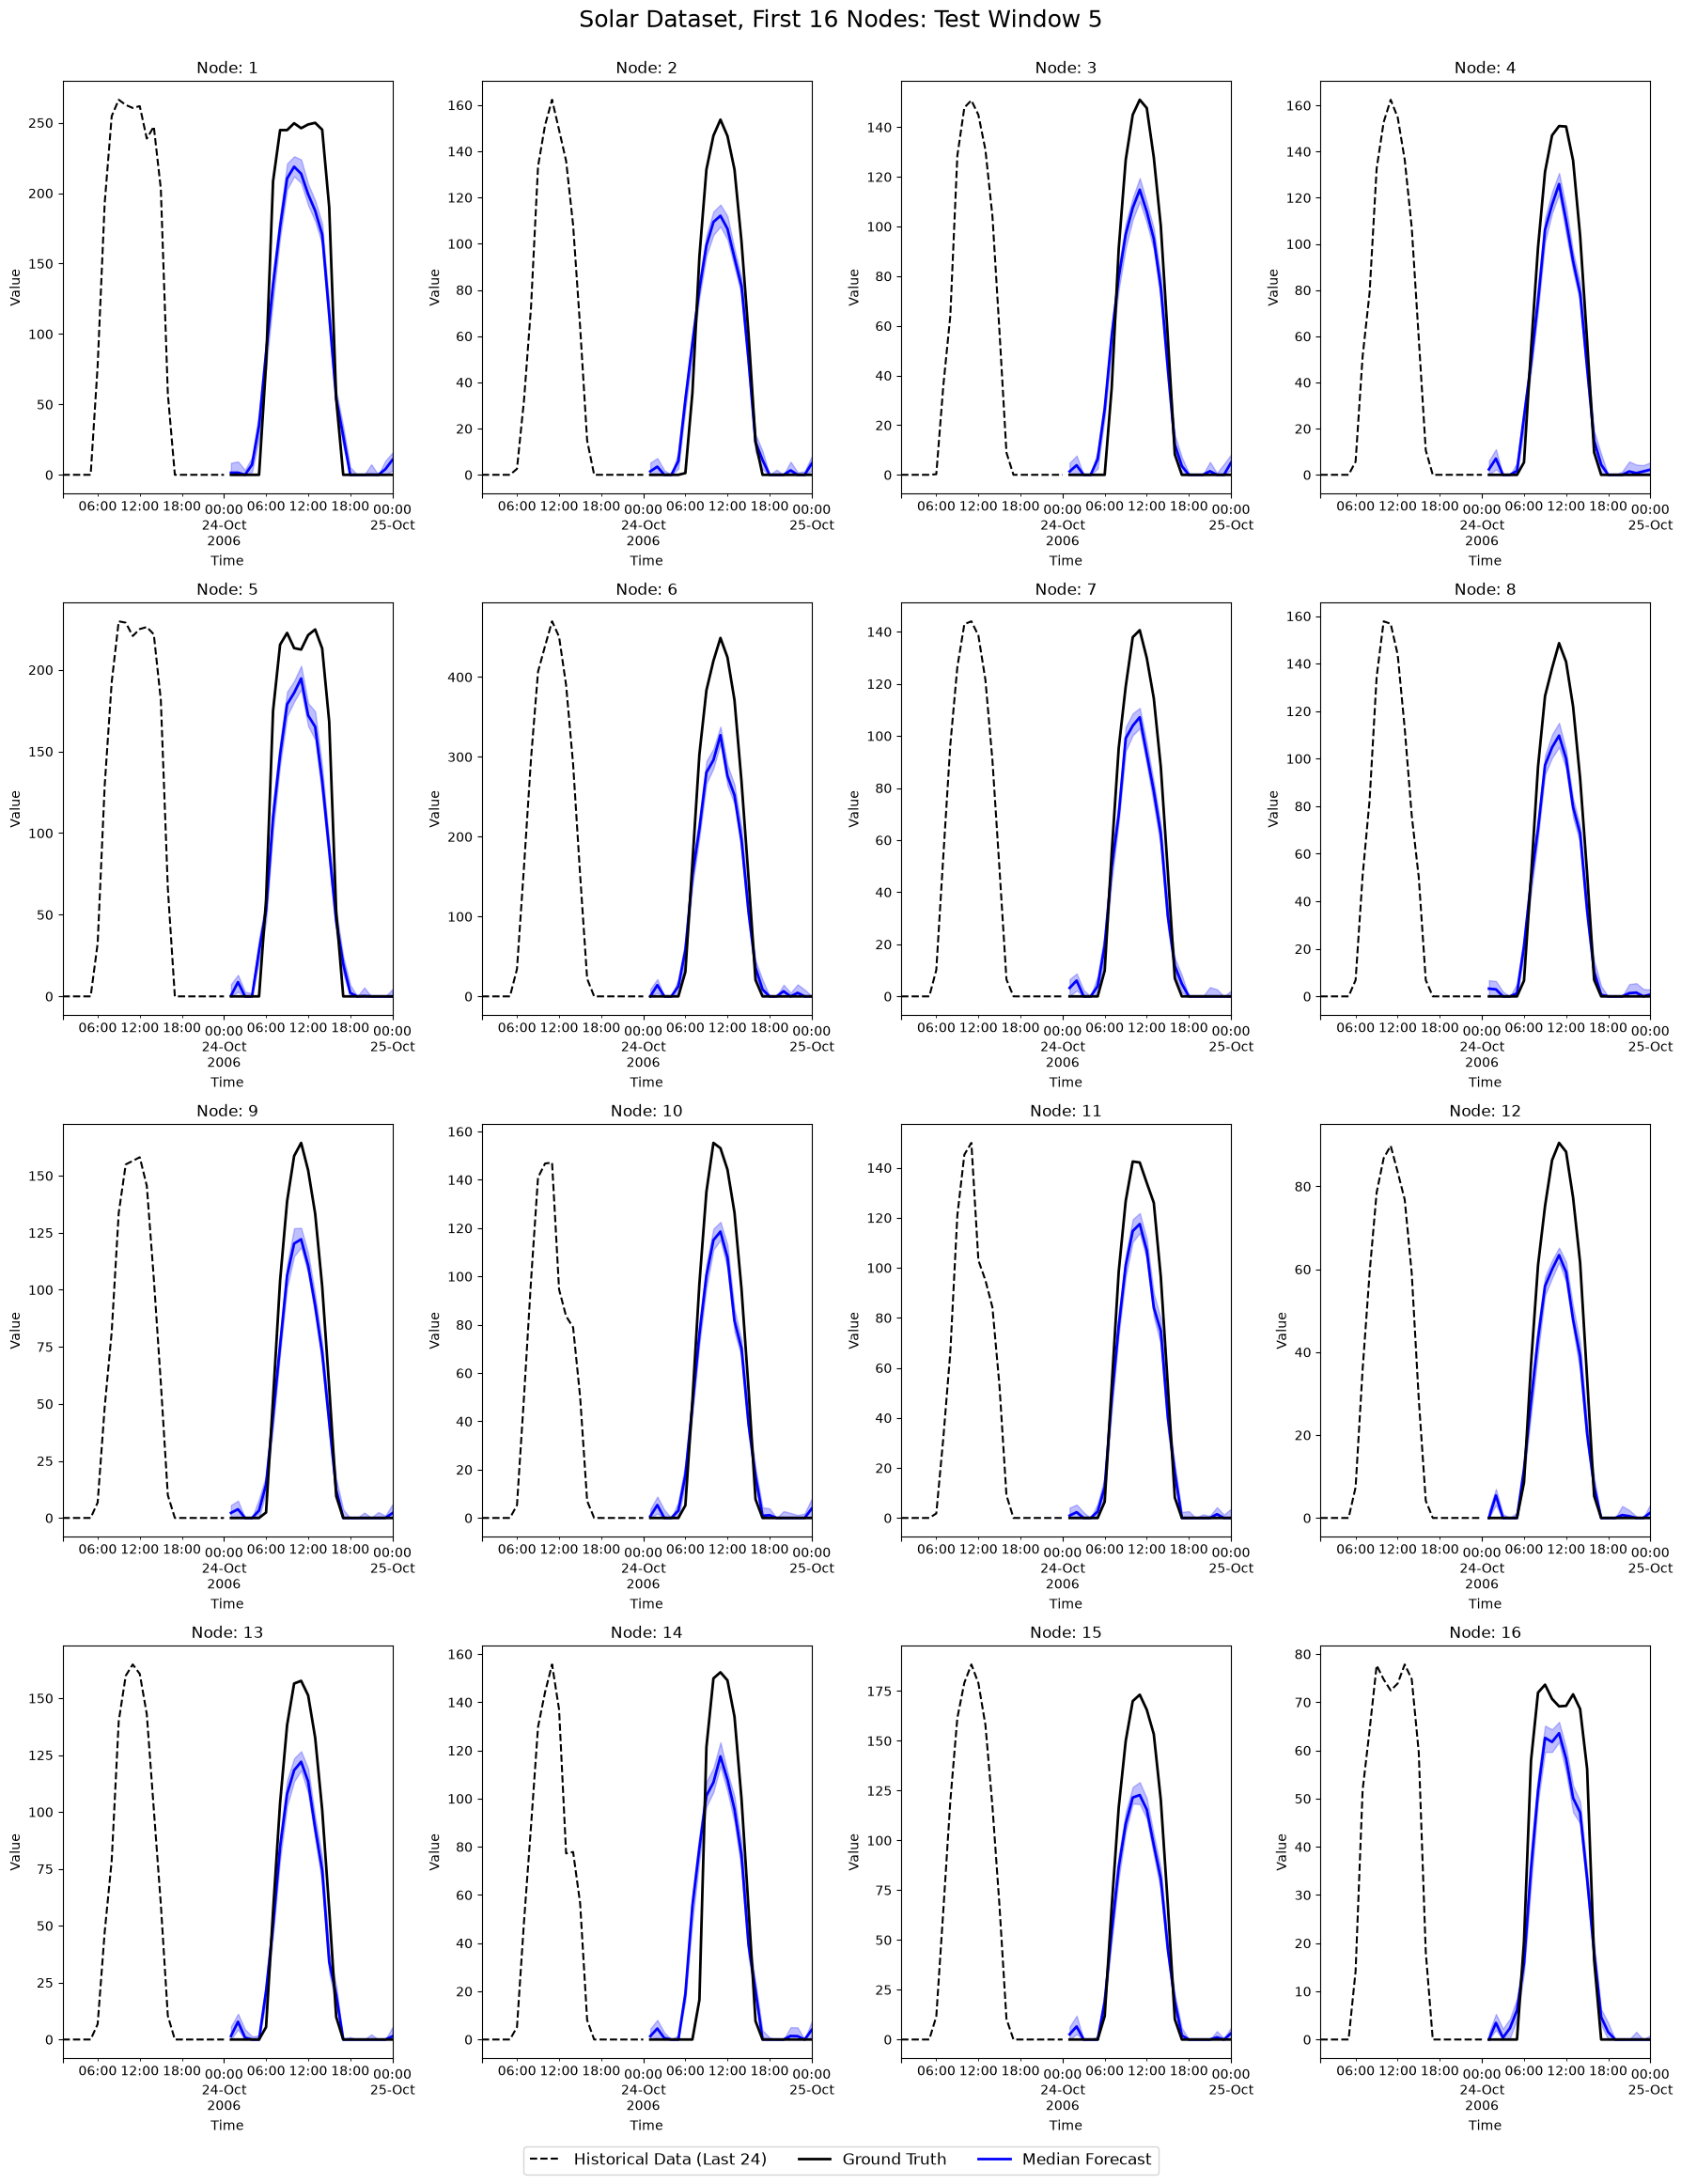

In [ ]:
import matplotlib.pyplot as plt
lags = LAGS
pred_len=24
history_hours = 24
full_ts = TimeSeries.from_dataframe(test_windows[4]).astype(np.float32)
full_sc = y_scaler.transform(full_ts).astype(np.float32)
full_pc = build_past_covs_552(full_sc, lags=lags).astype(np.float32)

full_sc = full_sc.slice_intersect(full_pc)
full_ts = full_ts.slice_intersect(full_sc)
full_pc = full_pc.slice_intersect(full_sc)

past_true_sc = full_sc[-2*pred_len:-pred_len]
gt_future    = full_ts[-pred_len:]

forecast_start = gt_future.start_time()          
pc_past = ts_upto(full_pc, forecast_start)      

#print(f"Past Values are {past_true_sc}")
#model.model.encoder[0].reset_std(2)
# EnHiTS has no encoder/reset_seed/reset_std
fc_sc = model.predict(
    pred_len,
    series=past_true_sc,
    past_covariates=pc_past,
    num_samples=100,
    verbose=False,
)
print(fc_sc.shape)
fc = y_scaler.inverse_transform(fc_sc)
fc = fc.with_values(np.clip(fc.all_values(), a_min=0, a_max=None))

print(fc.shape)

forecast_unscaled = fc

# Ensure training data is also unscaled for plotting
# 'train' should be your original unscaled training TimeSeries
train_unscaled = full_ts[-2*pred_len:-pred_len]
actual_unscaled = gt_future

first_10_names = list(forecast_unscaled.components[:16])

# Subsetting
forecast_sub = forecast_unscaled[first_10_names]
actual_sub = actual_unscaled[first_10_names]
train_sub = train_unscaled[first_10_names]

import matplotlib.pyplot as plt

# 1. Enforce default matplotlib style
plt.style.use('default')

# Create figure and axes explicitly to manage the layout better
fig, axes = plt.subplots(4, 4, figsize=(18, 25))
axes = axes.flatten()

# Add a main title to the overall figure
fig.suptitle("Solar Dataset, First 16 Nodes: Test Window 5", fontsize=18, y=0.96)

for i in range(16):
    ax = axes[i]
    plt.sca(ax)  # Set current axis for Darts
    
    # Plot Last 24 points of Training Data
    train_sub.univariate_component(i).plot(
        label="Historical Data (Last 24)", 
        color="black", 
        linestyle="--", 
        linewidth=1.5
    )
    
    # Plot Ground Truth (Actuals)
    actual_sub.univariate_component(i).plot(
        label="Ground Truth", 
        color="black", 
        linewidth=2,
        zorder=10 
    )
    
    # Forecast Layer: 95% CI + Median
    forecast_sub.univariate_component(i).plot(
        central_quantile=0.5,    
        low_quantile=0.025,      # 2.5th percentile
        high_quantile=0.975,     # 97.5th percentile
        label="Median Forecast", # Updated label
        color="blue",
        alpha=0.25                # Single interval with 0.3 opacity
    )
    
    ax.set_title(f"Node: {i+1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    
    # Darts sometimes automatically adds a legend; we remove it here to keep subplots clean
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# 2. Extract handles and labels for the unified legend
handles, labels = ax.get_legend_handles_labels()

# Deduplicate in case multiple calls generated duplicate labels
by_label = dict(zip(labels, handles))

# 3. Create a single figure-level legend at the bottom center
fig.legend(
    by_label.values(), 
    by_label.keys(), 
    loc='lower center', 
    ncol=3,                     # Reduced to 3 columns to match the 3 legend items
    fontsize='large', 
    bbox_to_anchor=(0.5, 0.035) 
)

# 4. Adjust layout
plt.tight_layout(rect=[0, 0.05, 1, 0.96]) 
plt.savefig("Solar_Forecasts.pdf", format='pdf')
plt.show()

In [ ]:
vals = fc.all_values()

print("fc.shape:", fc.shape)
print("all_values shape:", vals.shape)

print("timesteps =", vals.shape[0])
print("nodes      =", vals.shape[1])

if vals.ndim == 3:
    print("samples    =", vals.shape[2])
elif vals.ndim == 2:
    print("No sample dimension present (deterministic output)")
else:
    print("Unexpected shape!")

fc.shape: (24, 137, 100)
all_values shape: (24, 137, 100)
timesteps = 24
nodes      = 137
samples    = 100


In [ ]:
lst = []

start = time.time()
for i in range(10):
    lst.append(
        get_crps(
            model,
            test_windows,
            y_scaler,
            seed=SEED + i,
        )
    )
end = time.time()

print("Inference time:", (end - start))
print(np.mean(lst))

c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])
Inference time: 55.57992076873779
0.4433561200300461


In [ ]:
lst = []
seeds = [60, 167, 221, 432, 264, 253, 266, 496, 151, 99]

from tqdm import tqdm

for i in tqdm(seeds):
    lst.append(
        get_crps(
            model,
            test_windows,
            y_scaler,
            seed=i,
        )
    )

print(np.mean(lst), np.std(lst))

  0%|          | 0/10 [00:00<?, ?it/s]c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


c:\Users\Anusha\engression\engression-ts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


<class 'tuple'>
3
0 torch.Size([64, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([64, 24, 689])
Final output: torch.Size([64, 24, 137, 1])
<class 'tuple'>
3
0 torch.Size([36, 24, 689]) torch.float32
1 None
2 None
Input: torch.Size([36, 24, 689])
Final output: torch.Size([36, 24, 137, 1])


100%|██████████| 10/10 [01:16<00:00,  7.68s/it]

0.4429894147441583 0.000574223641778294


## Optimization

In [ ]:
import pickle
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
import numpy as np

# --- 1. Search Space ---
search_space = {
    "std": hp.uniform("std", 0.5, 3.0),
    "engression_m": hp.quniform("engression_m", 2, 8, 2),
    "learning_rate": hp.qloguniform(
        "learning_rate", np.log(1e-5), np.log(1e-2), 1e-5
    ),
    "batch_size": hp.quniform("batch_size", 32, 128, 32),
}

# --- 2. Objective Function ---
def objective(params):

    SEED = 42
    deterministic.init_all(SEED)
    pl.seed_everything(SEED, workers=True)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=False)

    try:
        model = EnBEATSModel(
            input_chunk_length=24,
            output_chunk_length=24,
            noise_std=params["std"],
            num_samples_engression=int(params["engression_m"]),
            optimizer_kwargs={"lr": params["learning_rate"]},
            batch_size=int(params["batch_size"]),
            random_state=SEED,
            n_epochs=30,
            noise_dist="uniform",
        )

        model.fit(
            train_y_sc,
            past_covariates=train_pc,
            verbose=True,
            dataloader_kwargs={"num_workers": 0},
        )

        crps_list = []
        for i in range(10):
            crps_list.append(
                get_crps(
                    model,
                    test_windows,
                    y_scaler,
                    seed=SEED + i,
                )
            )

        mean_crps = np.mean(crps_list)
        std_crps = np.std(crps_list)

        print(f"Got Result {mean_crps} +/- {std_crps} for {params}")

        return {
            "loss": mean_crps,
            "status": STATUS_OK,
            "crps_list": crps_list,
        }

    except Exception as e:
        print(f"Trial failed: {e}")
        return {"loss": 1e6, "status": STATUS_OK}


# --- 3. Hyperopt Loop ---
trials_step = 5
max_trials = 50
trials_file = "hyperopt_trials_enhits.pkl"

try:
    with open(trials_file, "rb") as f:
        trials = pickle.load(f)
    print(f"Found existing trials. Resuming from {len(trials.trials)} runs.")
except:
    trials = Trials()

for i in range(len(trials.trials) + trials_step, max_trials + trials_step, trials_step):
    best = fmin(
        fn=objective,
        space=search_space,
        algo=tpe.suggest,
        max_evals=i,
        trials=trials,
        rstate=np.random.default_rng(SEED),
    )

    with open(trials_file, "wb") as f:
        pickle.dump(trials, f)

    print(f"Checkpoint saved at {i} trials. Best so far: {best}")

ModuleNotFoundError: No module named 'hyperopt'